In [ ]:
import os
import pandas as pd
import numpy as np

# ========================
# ==== CONFIG ============
# ========================

BASE_RESULTS_PATH = "RESULTADOS_FINAIS_BENCHMARK/results_benchmark"

# Pontos (séries/colunas) cujo erro "estoura" numericamente (ex.: 7.3e+17)
# distorcem completamente as comparações. Qualquer ponto em que ALGUM modelo
# apresente |valor| > EXPLOSION_THRESHOLD é descartado para TODOS os modelos
# daquele benchmark, mantendo o alinhamento das comparações.
EXPLOSION_THRESHOLD = 1e6


def drop_exploded_points(df, dataset_name="", config_name="", threshold=EXPLOSION_THRESHOLD):
    """Remove os pontos com valores estourados (|valor| > threshold) de todos os
    modelos e informa quais pontos foram descartados. Retorna (df_limpo, pontos_descartados)."""
    metric_cols = [c for c in df.columns if c != "Modelo" and not str(c).startswith("Unnamed")]
    numeric = df[metric_cols].apply(pd.to_numeric, errors="coerce")
    exploded_mask = (numeric.abs() > threshold).any(axis=0)
    dropped = [c for c in metric_cols if bool(exploded_mask.get(c, False))]
    if dropped:
        label = dataset_name + (f" / {config_name}" if config_name else "")
        print(f"[ESTOURO] {label}: pontos descartados (|valor| > {threshold:g}): {dropped}")
    return df.drop(columns=dropped), dropped

DATASETS = {
    "cif_2016_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "etth_filtered":            {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "fred_bls_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    "fred_md_filtered":         {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.0001"},
    "hospital_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    "m3_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "m4_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "nn5_weekly_filtered":      {"horizon": 8,  "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "tourism_monthly_filtered": {"horizon": 24, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.0001"},
    "walmart_sales_filtered":   {"horizon": 5, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.0001"},
    "weather_filtered":         {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
}

all_data = []
dropped_points_log = {}

# ========================
# ==== LOAD & MERGE ======
# ========================
for dataset_name, info in DATASETS.items():
    config = info["best_config"]
    horizon = info["horizon"]
    file_path = os.path.join(BASE_RESULTS_PATH, config, f"results_{dataset_name}.csv")

    if not os.path.exists(file_path):
        print(f"Arquivo não encontrado: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # Descarta pontos estourados (mesmos pontos para todos os modelos)
    df, dropped = drop_exploded_points(df, dataset_name, config)
    if dropped:
        dropped_points_log[dataset_name] = dropped

    metric_cols = [c for c in df.columns if c != "Modelo" and not c.startswith("Unnamed")]

    df_long = df[["Modelo"] + metric_cols].melt(
        id_vars=["Modelo"],
        var_name="Serie",
        value_name="MAPE"
    )

    df_long["Horizonte"] = horizon  
    df_long["Dataset"] = dataset_name

    all_data.append(df_long)

# ========================
# ==== CLEANUP ===========
# ========================
df_all = pd.concat(all_data, ignore_index=True)

df_all = (
    df_all
    .replace([float("inf"), float("-inf")], pd.NA)
    .dropna(subset=["MAPE"])
)

if dropped_points_log:
    print("\nPontos descartados por estouro numérico:")
    for ds, pts in dropped_points_log.items():
        print(f"   - {ds}: {pts}")

print(df_all.head())

Computing Bayesian comparisons...
Generating plot...



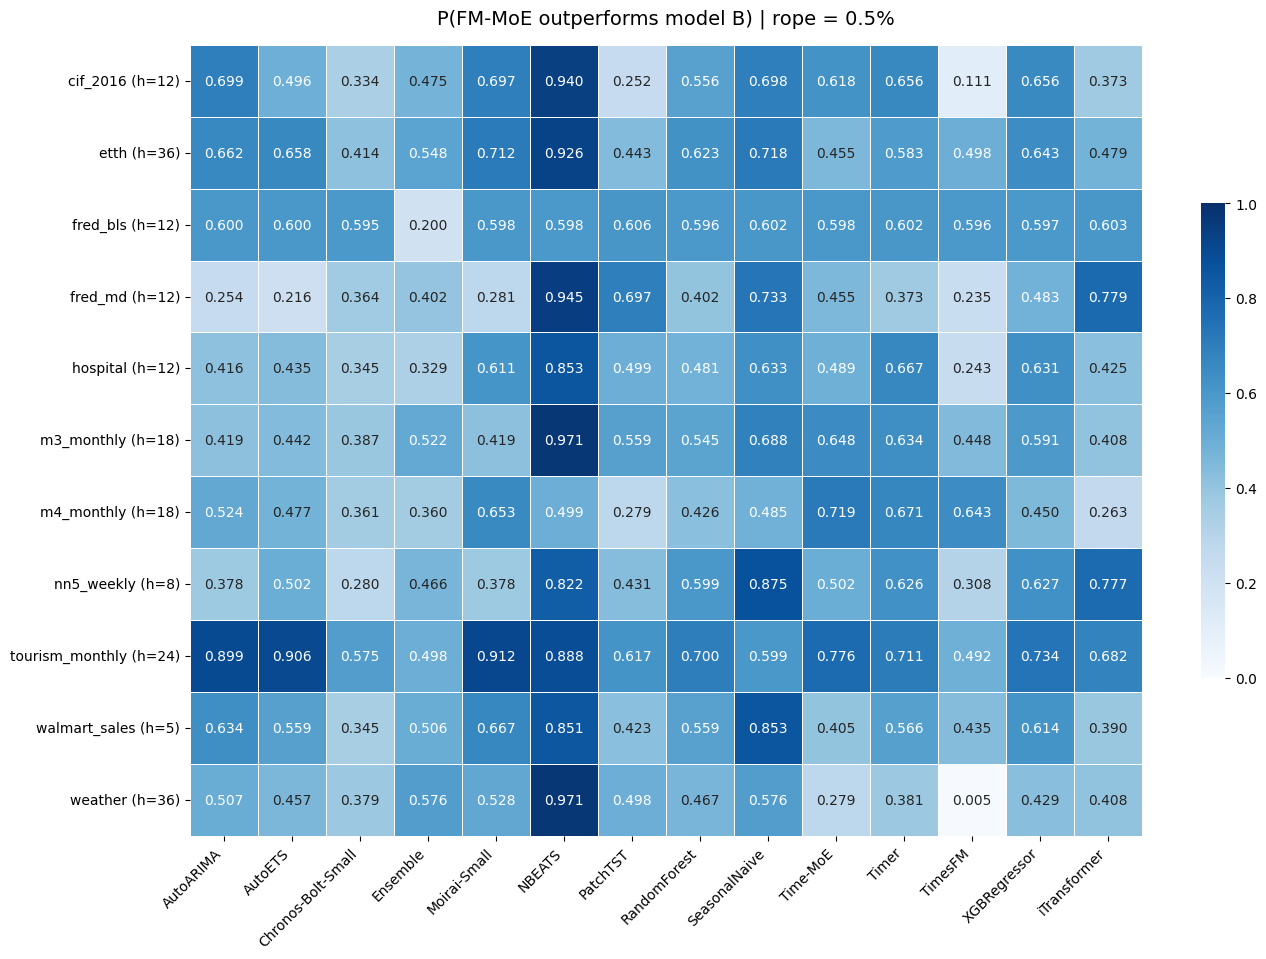

In [6]:
# ================================================
#  IMPORTS
# ================================================
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


# ================================================
#  RENAME MODEL
# ================================================
df_all["Modelo"] = df_all["Modelo"].replace("FM-MoE", "FM-MoE")
df_all["Modelo"] = df_all["Modelo"].replace("Morai", "Moirai")

MY_MODEL = "FM-MoE"

# ================================================
#  1. BAYESIAN SIGNED-RANK TEST
# ================================================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    diffs = np.array(differences)
    n_left = np.sum(diffs < -rope)
    n_rope = np.sum(np.abs(diffs) <= rope)
    n_right = np.sum(diffs > rope)
    alpha = np.array([n_left + s, n_rope + s, n_right + s])
    posterior = np.random.dirichlet(alpha, size=5000)
    return posterior[:, 0].mean(), posterior[:, 1].mean(), posterior[:, 2].mean()


# ================================================
#  2. BUILD COMBINED MATRIX (datasets x models)
# ================================================
def build_combined_matrix(df_all, my_model, rope=0.5, metric="MAPE"):
    rows = {}

    for dataset in sorted(df_all["Dataset"].unique()):
        subset = df_all[df_all["Dataset"] == dataset]

        if my_model not in subset["Modelo"].unique():
            continue

        horizon = subset["Horizonte"].iloc[0]
        row_label = f"{dataset.replace('_filtered', '')} (h={horizon})"

        others = sorted([m for m in subset["Modelo"].unique() if m != my_model])

        for B in others:
            dfA = subset[subset["Modelo"] == my_model][metric].values
            dfB = subset[subset["Modelo"] == B][metric].values

            if len(dfA) != len(dfB):
                continue

            diffs = dfB - dfA
            _, _, theta_right = bayesian_signed_rank(diffs, rope)

            if row_label not in rows:
                rows[row_label] = {}
            rows[row_label][B] = theta_right

    matrix = pd.DataFrame(rows).T
    matrix = matrix.reindex(columns=sorted(matrix.columns))
    return matrix


# ================================================
#  3. PLOT COMBINED HEATMAP
# ================================================
def plot_combined_heatmap(matrix, my_model, rope=0.5):
    n_rows = len(matrix)
    n_cols = len(matrix.columns)

    fig, ax = plt.subplots(figsize=(max(14, n_cols * 1.0), max(4, n_rows * 0.7 + 2)))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        cbar_kws={"shrink": 0.6},
        ax=ax
    )

    ax.set_title(
        f"P({my_model} outperforms model B) | rope = {rope}%",
        fontsize=14, pad=15
    )
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()


# =============================================================
#  4. RUN
# =============================================================
rope = 0.5

print("Computing Bayesian comparisons...")
matrix = build_combined_matrix(df_all, MY_MODEL, rope=rope, metric="MAPE")

print("Generating plot...\n")
plot_combined_heatmap(matrix, MY_MODEL, rope=rope)

In [8]:
import os
import numpy as np
import pandas as pd

# ========================
# CONFIG
# ========================
BASE_RESULTS_PATH = "RESULTADOS_FINAIS_BENCHMARK/results_benchmark"
MY_MOE_NAME = "FM-MoE"
ROPE = 0.5
TOP_K = 5

# Pontos cujo erro "estoura" numericamente (ex.: 7.3e+17). Qualquer ponto em
# que ALGUM modelo apresente |valor| > EXPLOSION_THRESHOLD é descartado para
# TODOS os modelos daquele arquivo (config + dataset).
EXPLOSION_THRESHOLD = 1e6


def drop_exploded_points(df, dataset_name="", config_name="", threshold=EXPLOSION_THRESHOLD):
    """Remove os pontos com valores estourados (|valor| > threshold) de todos os
    modelos e informa quais pontos foram descartados. Retorna (df_limpo, pontos_descartados)."""
    metric_cols = [c for c in df.columns if c != "Modelo" and not str(c).startswith("Unnamed")]
    numeric = df[metric_cols].apply(pd.to_numeric, errors="coerce")
    exploded_mask = (numeric.abs() > threshold).any(axis=0)
    dropped = [c for c in metric_cols if bool(exploded_mask.get(c, False))]
    if dropped:
        label = dataset_name + (f" / {config_name}" if config_name else "")
        print(f"[ESTOURO] {label}: pontos descartados (|valor| > {threshold:g}): {dropped}")
    return df.drop(columns=dropped), dropped


# ========================
# BAYESIAN FUNCTIONS
# ========================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    diffs = np.array(differences)
    n_left  = np.sum(diffs < -rope)
    n_rope  = np.sum(np.abs(diffs) <= rope)
    n_right = np.sum(diffs > rope)
    alpha = np.array([n_left + s, n_rope + s, n_right + s])
    posterior = np.random.dirichlet(alpha, size=5000)
    return posterior.mean(axis=0)


def prob_A_better_than_B(df, A, B, rope=0.5, metric="MAPE"):
    dfA = df[df["Modelo"] == A][metric].values
    dfB = df[df["Modelo"] == B][metric].values
    if len(dfA) != len(dfB):
        raise ValueError(f"{A} e {B} com tamanhos diferentes.")
    diffs = dfB - dfA
    _, _, theta_A_better = bayesian_signed_rank(diffs, rope)
    return theta_A_better


# ========================
# PROCESSAMENTO
# ========================

results_by_dataset = {}
dropped_points_log = {}

for config_name in sorted(os.listdir(BASE_RESULTS_PATH)):
    config_path = os.path.join(BASE_RESULTS_PATH, config_name)
    if not os.path.isdir(config_path):
        continue

    for file in os.listdir(config_path):
        if not file.endswith(".csv"):
            continue

        dataset_name = file.replace(".csv", "")

        df = pd.read_csv(os.path.join(config_path, file))

        # Descarta pontos estourados (mesmos pontos para todos os modelos)
        df, dropped = drop_exploded_points(df, dataset_name, config_name)
        if dropped:
            dropped_points_log.setdefault(dataset_name, {})[config_name] = dropped

        # Identifica colunas de métricas (tudo exceto "Modelo")
        metric_cols = [c for c in df.columns if c != "Modelo"]

        df_long = df.melt(
            id_vars=["Modelo"],
            var_name="Serie",
            value_name="MAPE"
        )

        df_long = (
            df_long
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["MAPE"])
        )

        modelos = df_long["Modelo"].unique()
        my_moe_models = [m for m in modelos if MY_MOE_NAME in m]

        if not my_moe_models:
            continue

        my_moe = my_moe_models[0]

        row = {
            "Config": config_name,
            "Dataset": dataset_name
        }

        probs = []

        for other_model in modelos:
            if other_model == my_moe:
                continue
            try:
                p = prob_A_better_than_B(df_long, my_moe, other_model, rope=ROPE)
                row[f"Prob_MyMoE_vs_{other_model}"] = p
                probs.append(p)
            except ValueError:
                continue

        if not probs:
            continue

        row["Score_Medio_MyMoE"] = np.mean(probs)

        if dataset_name not in results_by_dataset:
            results_by_dataset[dataset_name] = []

        results_by_dataset[dataset_name].append(row)

# ========================
# RANKING POR DATASET
# ========================

print("\n")

if dropped_points_log:
    print("=" * 80)
    print("PONTOS DESCARTADOS POR ESTOURO NUMÉRICO")
    print("=" * 80)
    for dataset, by_config in sorted(dropped_points_log.items()):
        print(f"{dataset}:")
        for cfg, pts in sorted(by_config.items()):
            print(f"   - {cfg}: {pts}")
    print("\n")

for dataset, rows in sorted(results_by_dataset.items()):
    df_d = pd.DataFrame(rows)
    df_d = df_d.sort_values("Score_Medio_MyMoE", ascending=False).reset_index(drop=True)

    print("=" * 80)
    print(f"TOP {TOP_K} CONFIGS — {dataset}")
    print("=" * 80)
    print(df_d.head(TOP_K).to_string(index=False))
    print("\n")

[ESTOURO] results_etth_filtered / topk_1_norm_std_noise_True_ep_100_lr_0.0001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] results_fred_md_filtered / topk_1_norm_std_noise_True_ep_100_lr_0.0001: pontos descartados (|valor| > 1e+06): ['71', '73']
[ESTOURO] results_etth_filtered / topk_1_norm_std_noise_True_ep_100_lr_0.001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] results_fred_md_filtered / topk_1_norm_std_noise_True_ep_100_lr_0.001: pontos descartados (|valor| > 1e+06): ['71', '73']
[ESTOURO] results_etth_filtered / topk_1_norm_std_noise_True_ep_100_lr_1e-05: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] results_fred_md_filtered / topk_1_norm_std_noise_True_ep_100_lr_1e-05: pontos descartados (|valor| > 1e+06): ['71', '73']
[ESTOURO] results_etth_filtered / topk_1_norm_std_noise_True_ep_30_lr_0.0001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] results_fred_md_filtered / t